<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/FUSION_GEDI_RS_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.mdpi.com/2072-4292/13/3/442
https://iopscience.iop.org/article/10.1088/1748-9326/ab9e99/meta
https://dataverse.jpl.nasa.gov/file.xhtml?fileId=64312&version=3.0

https://www.neonscience.org/field-sites/guan
https://www.neonscience.org/field-sites/guan#field-site-data
https://data.neonscience.org/data-products/explore
https://data.neonscience.org/data-products/DP1.10098.001

# Setup

In [1]:
# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.6 MB/s eta 0:00:00


In [2]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()


In [3]:

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000


In [5]:
s1Ascending_2022 = ee.Image("projects/servir-sco-assets/assets/PR/s1Ascending_2022")
s1Descending_2022 = ee.Image("projects/servir-sco-assets/assets/PR/s1Descending_2022")
DEMindices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/DEMindices_2022")
GEDIindicesA_2022 = ee.Image("projects/servir-sco-assets/assets/PR/GEDIindicesA_2022")
GEDIindicesB_2022 = ee.Image("projects/servir-sco-assets/assets/PR/GEDIindicesB_2022")
HLS_2022 = ee.Image("projects/servir-sco-assets/assets/PR/HLS_2022")
LandsatComposite_2022 = ee.Image("projects/servir-sco-assets/assets/PR/LandsatComposite_2022")
LandsatIndices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/LandsatIndices_2022")
S2Composite_2022 = ee.Image("projects/servir-sco-assets/assets/PR/S2Composite_2022")
S2Indices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/S2Indices_2022")
landsatTasseledCapIndices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/landsatTasseledCapIndices_2022")
ROI = ee.FeatureCollection('users/tjm0042/PHD/PR/GUAN_724000_1987000')

Map.addLayer(ROI, {}, 'ROI')
Map.addLayer(s1Ascending_2022, {}, 's1Ascending_2022')
Map.addLayer(s1Descending_2022, {}, 's1Descending_2022')
Map.addLayer(DEMindices_2022, {}, 'DEMindices_2022')
Map.addLayer(GEDIindicesA_2022, {}, 'GEDIindicesA_2022')
Map.addLayer(GEDIindicesB_2022, {}, 'GEDIindicesB_2022')
Map.addLayer(HLS_2022, {}, 'HLS_2022')
Map.addLayer(LandsatComposite_2022, {}, 'LandsatComposite_2022')
Map.addLayer(LandsatIndices_2022, {}, 'LandsatIndices_2022')
Map.addLayer(S2Composite_2022, {}, 'S2Composite_2022')
Map.addLayer(S2Indices_2022, {}, 'S2Indices_2022')
Map.addLayer(landsatTasseledCapIndices_2022, {}, 'landsatTasseledCapIndices_2022')


#stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(HLS_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(S2Composite_2022).addBands(S2Indices_2022).addBands(landsatTasseledCapIndices_2022)

stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(landsatTasseledCapIndices_2022).addBands(HLS_2022).addBands(S2Composite_2022).addBands(S2Indices_2022)


#.addBands(GEDIindicesA_2022)
#.addBands(GEDIindicesB_2022)

Map.addLayer(stacked, {}, 'stacked');


Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [6]:
y_stacked = GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")## GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
#print(y_stacked.bandNames())
#y_stacked = GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
#print(y_stacked.bandNames())

Map.addLayer(y_stacked, {}, 'y_stacked');

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

# Fusion

In [7]:
#//////////////////////////////////////////////////////////////////////////////////
glad = ee.Image("projects/glad/GLCLU2020/Forest_height_2020").clip(ROI)
Map.addLayer(glad, {}, "glad")
glad = glad.gte(1).select(['b1']).rename(['class']);
#print("glad", glad)

classMask = GEDIindicesA_2022.addBands(glad)
Map.addLayer(classMask, {}, "classMask")
#print("classMask", classMask)


proj = s1Ascending_2022.projection()
grid = ROI.geometry().coveringGrid(proj, 10)
grid = ee.FeatureCollection(grid).randomColumn("random", 42);
#print("spatial_partition number of boxes in the grid", grid.size())
val_samp = grid.filter('random <= 0.1').set("samp_type","val_samp");
test_samp = grid.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
train_samp = grid.filter('random >= 0.3').set("samp_type","train_samp");


#rint('val_samp 10%', val_samp.size());
Map.addLayer(val_samp, {"color": "blue"}, "val_samp 10%")

#print('test_samp 20%', test_samp.size());
Map.addLayer(test_samp, {"color": "red"}, "test_samp 20%")

#print('train_samp 70%', train_samp.size());
Map.addLayer(train_samp, {"color": "green"}, "train_samp 70%")

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [8]:
training = geemap.ee_to_numpy(stacked, region=train_samp)
print(training.shape)
# print(training)

testing = geemap.ee_to_numpy(stacked, region=test_samp)
print(testing.shape)
# print(testing)

validation = geemap.ee_to_numpy(stacked, region=val_samp)
print(validation.shape)
# print(validation)

(102, 107, 45)
(102, 107, 45)
(102, 107, 45)


In [9]:
y_stacked = GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
#print(y_stacked.bandNames())

# Map.addLayer(y_stacked, {}, 'y_stacked');

# Map


In [10]:
y_trainining = geemap.ee_to_numpy(y_stacked, region=train_samp)
print(y_trainining.shape)
# print(validation)

y_testing = geemap.ee_to_numpy(y_stacked, region=test_samp)
print(y_testing.shape)
# print(validation)

y_validation = geemap.ee_to_numpy(y_stacked, region=val_samp)
print(y_validation.shape)
# print(validation)

(103, 103, 1)
(103, 103, 1)
(103, 103, 1)


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Conv2D, Concatenate, Cropping2D, Add
# from tensorflow.keras.optimizers import Adam
# from sklearn.metrics import mean_squared_error, r2_score


# # Mock input data for demonstration
# X_train = training
# print(X_train.shape)
# y_train = y_trainining
# print(y_train.shape)
# X_test = testing
# print(X_test.shape)
# y_test = y_testing
# print(y_test.shape)
# X_val = validation
# print(X_val.shape)
# y_val = y_validation
# print(y_val.shape)



# def sanitize_array(arr):
#     arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
#     arr = np.clip(arr, -1e5, 1e5)  # Adjust this range as appropriate for your domain
#     return arr.astype(np.float32)


# X_train = sanitize_array(X_train)
# X_test = sanitize_array(X_test)
# X_val = sanitize_array(X_val)
# y_train = sanitize_array(y_train)
# y_test = sanitize_array(y_test)
# y_val = sanitize_array(y_val)




# # Pad X data so the output can match 103x103
# def pad_input(X):
#     return np.expand_dims(np.pad(X, ((1, 0), (0, 0), (0, 0))), axis=0)

# X_train = pad_input(X_train)
# X_test = pad_input(X_test)
# X_val = pad_input(X_val)
# y_train = np.expand_dims(y_train, axis=0)
# y_test = np.expand_dims(y_test, axis=0)
# y_val = np.expand_dims(y_val, axis=0)

# # Split inputs for mid and late fusion
# def split_inputs(X):
#     SAR = X[:, :, :, 0:8]
#     dem = X[:, :, :, 8:10]
#     landsat = X[:, :, :, 10:33]
#     sentinel_2 = X[:, :, :, 33:45]
#     return SAR, dem, landsat, sentinel_2

# # Model builders
# def build_early_fusion(input_shape):
#     inputs = Input(shape=input_shape)
#     x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Cropping2D(((0, 0), (2, 2)))(x)
#     x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
#     return Model(inputs, x)

# def build_mid_fusion():
#     input_SAR = Input(shape=(103, 107, 8))
#     input_dem = Input(shape=(103, 107, 2))
#     input_landsat = Input(shape=(103, 107, 23))
#     input_sentinel_2 = Input(shape=(103, 107, 12))

#     def block(x):
#         x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
#         x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
#         return x

#     x1 = block(input_SAR)
#     x2 = block(input_dem)
#     x3 = block(input_landsat)
#     x4 = block(input_sentinel_2)

#     x = Concatenate()([x1, x2, x3, x4])
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Cropping2D(((0, 0), (2, 2)))(x)
#     x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
#     return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], x)

# def build_late_fusion():
#     # input_sentinel = Input(shape=(103, 107, 20))
#     # input_dem = Input(shape=(103, 107, 2))
#     # input_landsat = Input(shape=(103, 107, 23))
#     input_SAR = Input(shape=(103, 107, 8))
#     input_dem = Input(shape=(103, 107, 2))
#     input_landsat = Input(shape=(103, 107, 23))
#     input_sentinel_2 = Input(shape=(103, 107, 12))

#     def block(x):
#         x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
#         x = Cropping2D(((0, 0), (2, 2)))(x)
#         return Conv2D(1, (1, 1), activation='linear', padding='same')(x)

#     y1 = block(input_SAR)
#     y2 = block(input_dem)
#     y3 = block(input_landsat)
#     y4 = block(input_sentinel_2)

#     y = Add()([y1, y2, y3, y4])
#     y = Conv2D(1, (1, 1), activation='linear', padding='same')(y)
#     return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], y)

# def compile_and_train(model, X, y, name):
#     model.compile(optimizer=Adam(), loss='mse')
#     history = model.fit(X, y, epochs=10, verbose=1)
#     y_pred = model.predict(X)

#     mse = mean_squared_error(y.flatten(), y_pred.flatten())
#     r2 = r2_score(y.flatten(), y_pred.flatten())
#     print(f"{name}-fusion MSE: {mse:.4f}, R^2: {r2:.4f}")

#     plt.plot(history.history['loss'])
#     plt.title(f'{name}-Fusion Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.show()

#     plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
#     plt.title(f'{name}-Fusion Prediction')
#     plt.colorbar()
#     plt.show()

# # Train and evaluate models
# model_early = build_early_fusion((103, 107, 45))
# compile_and_train(model_early, X_train, y_train, 'Early')

# sentinel_SAR, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
# model_mid = build_mid_fusion()
# compile_and_train(model_mid, [sentinel_SAR, dem_train, landsat_train, sentinel_train], y_train, 'Mid')

# model_late = build_late_fusion()
# compile_and_train(model_late, [sentinel_SAR, dem_train, landsat_train, sentinel_train], y_train, 'Late')

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.3169
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0690
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0761
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.0651
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0735
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.0666
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0694
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0688
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 0.0648
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - loss: 0.0667
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0664
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - loss: 0.0647
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 0.0659
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 0.0661
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.0646
Epoch 1

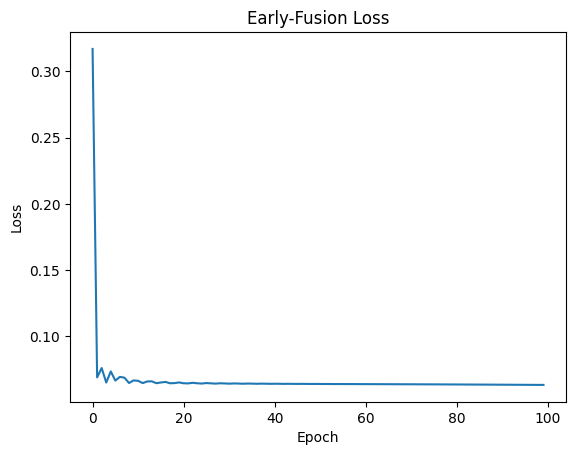

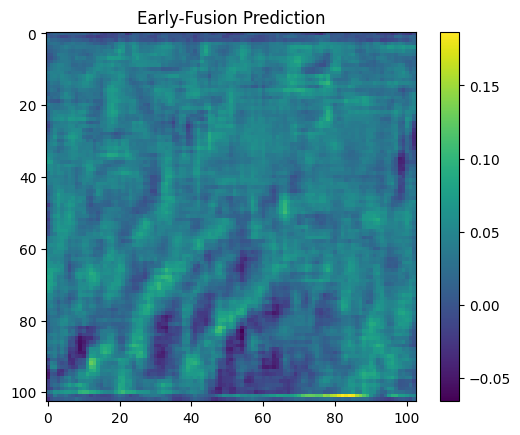

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0744
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.3494
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - loss: 0.0925
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - loss: 0.0713
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - loss: 0.0955
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step - loss: 0.0967
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - loss: 0.0845
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - loss: 0.0722
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - loss: 0.0658
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - loss: 0.0649
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - loss: 0.0666
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - loss: 0.0681
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 0.0686
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.0681
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.0671
Epoch 1

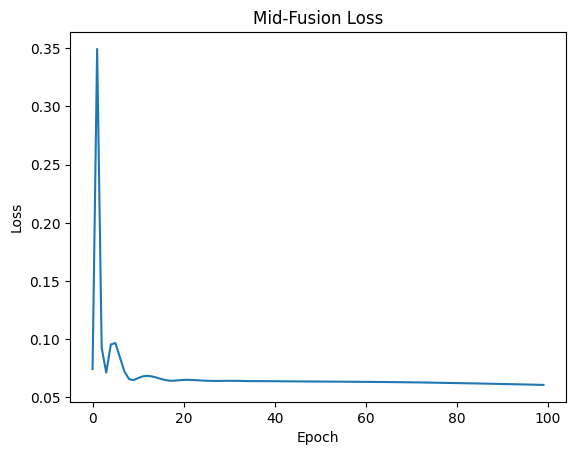

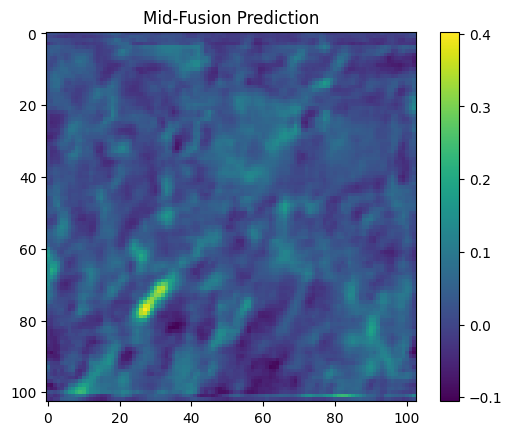

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3460
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0764
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1696
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.2073
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.1467
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0861
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0748
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1003
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.1240
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.1234
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.1033
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0812
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0714
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0765
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0885
Epoch 16/100
1

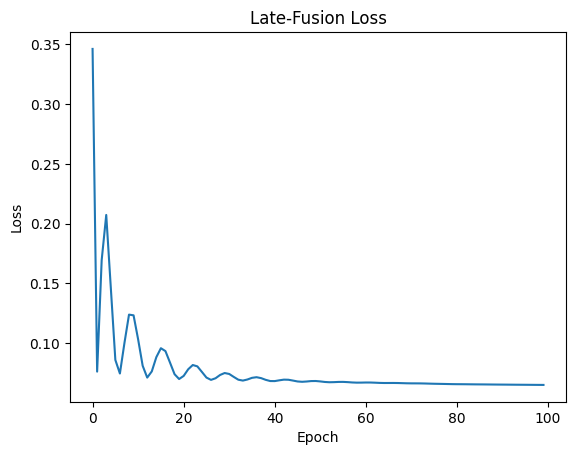

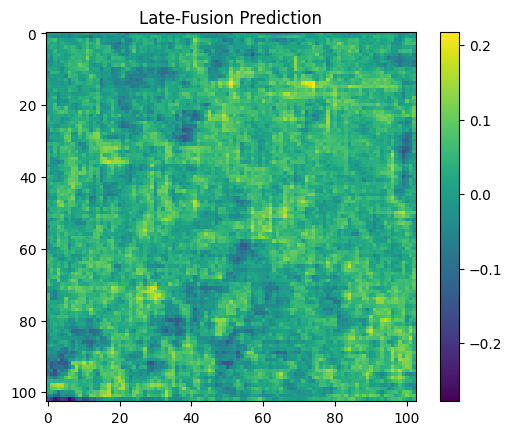

In [11]:
# this block includes scaling acorss all avaiable bands

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Concatenate, Cropping2D, Add
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# --- Load your training, testing, validation arrays ---
X_train = training
y_train = y_trainining
X_test = testing
y_test = y_testing
X_val = validation
y_val = y_validation

# -------------------------------
# Sanitize X and Y arrays
# -------------------------------
def sanitize_array(arr):
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr = np.clip(arr, -1e5, 1e5)
    return arr.astype(np.float32)

X_train = sanitize_array(X_train)
X_test = sanitize_array(X_test)
X_val = sanitize_array(X_val)
y_train = sanitize_array(y_train)
y_test = sanitize_array(y_test)
y_val = sanitize_array(y_val)

# -------------------------------
# Per-band MinMax scaling for X
# -------------------------------
def scale_per_band(X_train, X_test, X_val):
    n_bands = X_train.shape[-1]
    X_train_scaled = np.zeros_like(X_train)
    X_test_scaled = np.zeros_like(X_test)
    X_val_scaled = np.zeros_like(X_val)

    for i in range(n_bands):
        scaler = MinMaxScaler()
        train_band = X_train[:, :, i].reshape(-1, 1)
        test_band = X_test[:, :, i].reshape(-1, 1)
        val_band = X_val[:, :, i].reshape(-1, 1)

        scaler.fit(train_band)

        X_train_scaled[:, :, i] = scaler.transform(train_band).reshape(X_train.shape[0], X_train.shape[1])
        X_test_scaled[:, :, i] = scaler.transform(test_band).reshape(X_test.shape[0], X_test.shape[1])
        X_val_scaled[:, :, i] = scaler.transform(val_band).reshape(X_val.shape[0], X_val.shape[1])

    return X_train_scaled, X_test_scaled, X_val_scaled

X_train, X_test, X_val = scale_per_band(X_train, X_test, X_val)

# -------------------------------
# Pad X data to match output size
# -------------------------------
def pad_input(X):
    return np.expand_dims(np.pad(X, ((1, 0), (0, 0), (0, 0))), axis=0)

X_train = pad_input(X_train)
X_test = pad_input(X_test)
X_val = pad_input(X_val)
y_train = np.expand_dims(y_train, axis=0)
y_test = np.expand_dims(y_test, axis=0)
y_val = np.expand_dims(y_val, axis=0)

# -------------------------------
# Split inputs for mid and late fusion
# -------------------------------
def split_inputs(X):
    SAR = X[:, :, :, 0:8]
    dem = X[:, :, :, 8:10]
    landsat = X[:, :, :, 10:33]
    sentinel_2 = X[:, :, :, 33:45]
    return SAR, dem, landsat, sentinel_2

# -------------------------------
# Model builders (same as before)
# -------------------------------
def build_early_fusion(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model(inputs, x)

def build_mid_fusion():
    input_SAR = Input(shape=(103, 107, 8))
    input_dem = Input(shape=(103, 107, 2))
    input_landsat = Input(shape=(103, 107, 23))
    input_sentinel_2 = Input(shape=(103, 107, 12))

    def block(x):
        x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        return x

    x1 = block(input_SAR)
    x2 = block(input_dem)
    x3 = block(input_landsat)
    x4 = block(input_sentinel_2)

    x = Concatenate()([x1, x2, x3, x4])
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], x)

def build_late_fusion():
    input_SAR = Input(shape=(103, 107, 8))
    input_dem = Input(shape=(103, 107, 2))
    input_landsat = Input(shape=(103, 107, 23))
    input_sentinel_2 = Input(shape=(103, 107, 12))

    def block(x):
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = Cropping2D(((0, 0), (2, 2)))(x)
        return Conv2D(1, (1, 1), activation='linear', padding='same')(x)

    y1 = block(input_SAR)
    y2 = block(input_dem)
    y3 = block(input_landsat)
    y4 = block(input_sentinel_2)

    y = Add()([y1, y2, y3, y4])
    y = Conv2D(1, (1, 1), activation='linear', padding='same')(y)
    return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], y)

# -------------------------------
# Compile and train models
# -------------------------------
def compile_and_train(model, X, y, name):
    model.compile(optimizer=Adam(), loss='mse')
    history = model.fit(X, y, epochs=10, verbose=1)
    y_pred = model.predict(X)

    mse = mean_squared_error(y.flatten(), y_pred.flatten())
    r2 = r2_score(y.flatten(), y_pred.flatten())
    print(f"{name}-fusion MSE: {mse:.4f}, R^2: {r2:.4f}")

    plt.plot(history.history['loss'])
    plt.title(f'{name}-Fusion Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
    plt.title(f'{name}-Fusion Prediction')
    plt.colorbar()
    plt.show()

# -------------------------------
# Train models
# -------------------------------
model_early = build_early_fusion((103, 107, 45))
compile_and_train(model_early, X_train, y_train, 'Early')

SAR_train, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
model_mid = build_mid_fusion()
compile_and_train(model_mid, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, 'Mid')

model_late = build_late_fusion()
compile_and_train(model_late, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, 'Late')


Viz


----- Early Fusion Evaluation -----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Early MSE: 0.0633
Early RMSE: 0.2516
Early MAE: 0.0676
Early R²: 0.0168


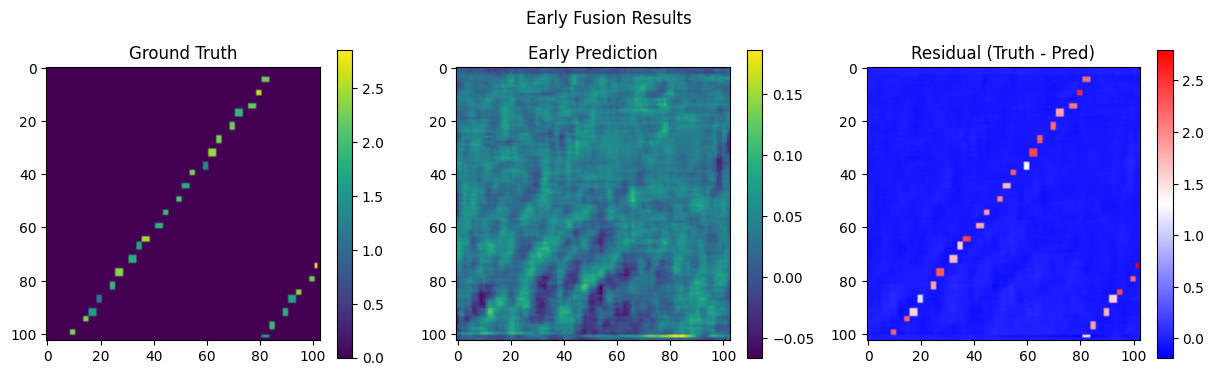


----- Mid Fusion Evaluation -----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Mid MSE: 0.0607
Mid RMSE: 0.2463
Mid MAE: 0.0663
Mid R²: 0.0578


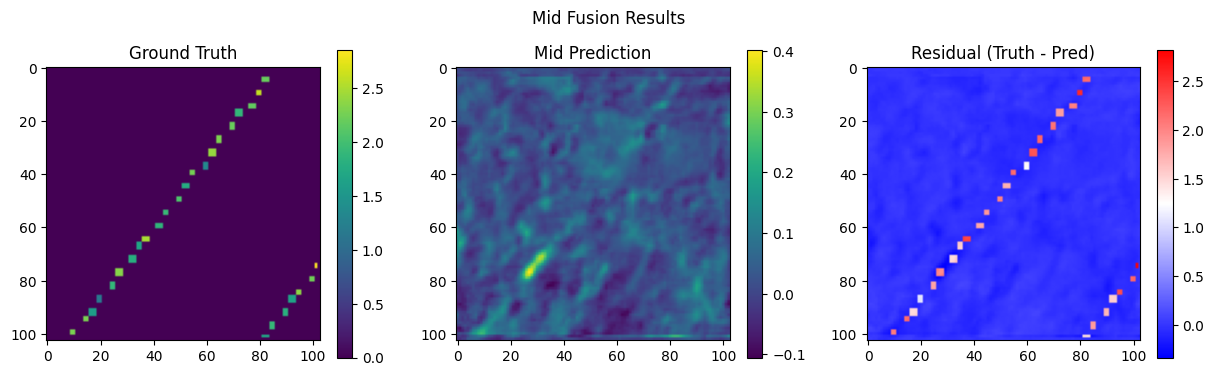


----- Late Fusion Evaluation -----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Late MSE: 0.0652
Late RMSE: 0.2554
Late MAE: 0.0746
Late R²: -0.0129


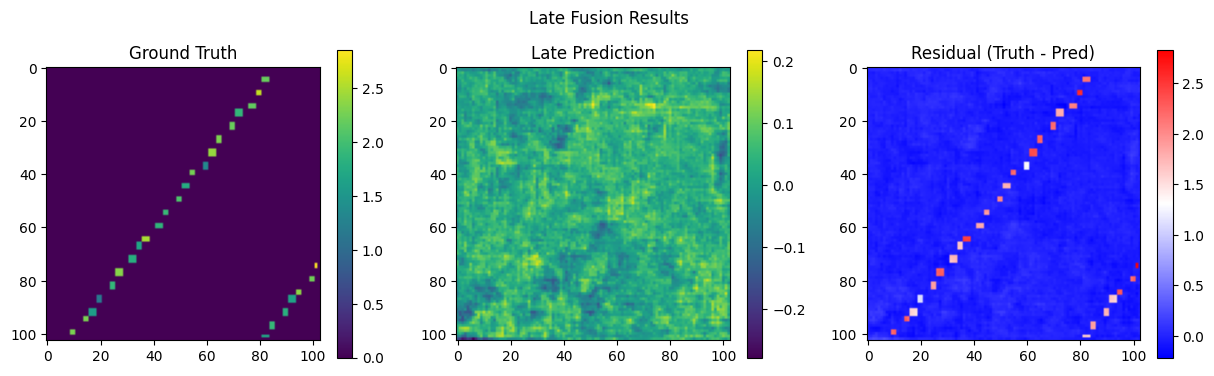

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def visualize_predictions(model, X_input, y_true, name):
    print(f"\n----- {name} Fusion Evaluation -----")

    # Predict
    y_pred = model.predict(X_input)

    # Flatten for stats
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    # Metrics
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mse)

    print(f"{name} MSE: {mse:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")
    print(f"{name} MAE: {mae:.4f}")
    print(f"{name} R²: {r2:.4f}")

    # Visualize
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(y_true[0, :, :, 0], cmap='viridis')
    plt.title('Ground Truth')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
    plt.title(f'{name} Prediction')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow((y_true[0, :, :, 0] - y_pred[0, :, :, 0]), cmap='bwr')
    plt.title('Residual (Truth - Pred)')
    plt.colorbar()

    plt.suptitle(f'{name} Fusion Results')
    plt.show()

# --- Run for Early ---
visualize_predictions(model_early, X_test, y_test, 'Early')

# --- Run for Mid ---
SAR_test, DEM_test, Landsat_test, Sentinel_test = split_inputs(X_test)
visualize_predictions(model_mid, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Mid')

# --- Run for Late ---
visualize_predictions(model_late, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Late')


Example with Feature importance early mid and late

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0755   
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.1378
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0753
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0657
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0671
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0659
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0649
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0646
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0645
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.0644
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0644
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0643
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0643
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0643
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0643
Epoc

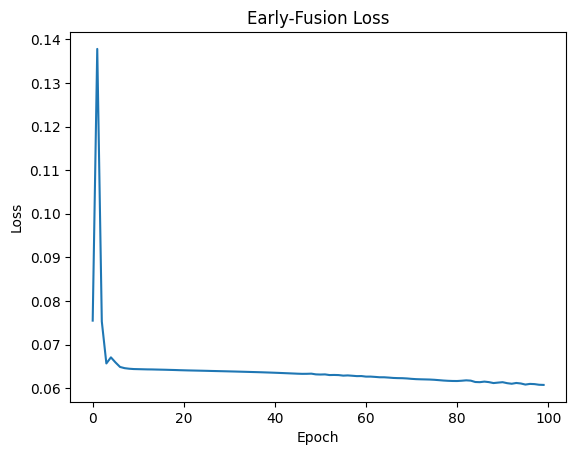

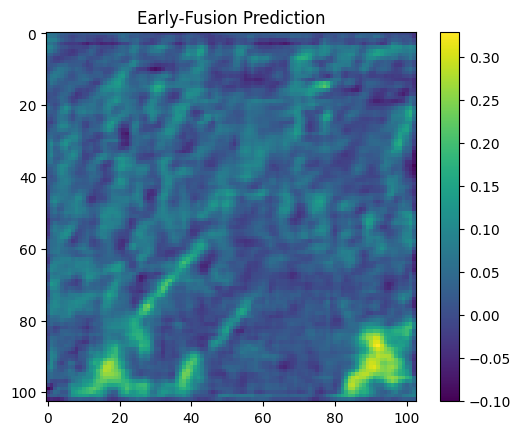

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

--- Early Fusion Feature Importance ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Band Band0: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Band Band1: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Band Band2: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Band Band3: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Band Band4: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Band Band5: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Band Band6: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Band Band7: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Band Band8: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Band Band9: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Band Band10: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Band Band11: MSE increase 0.000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Band Band12: MSE 

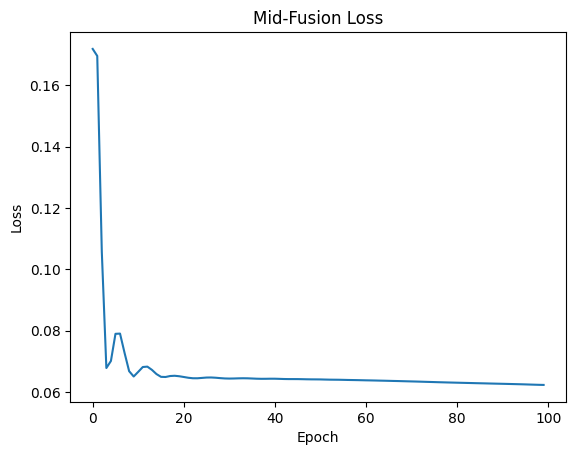

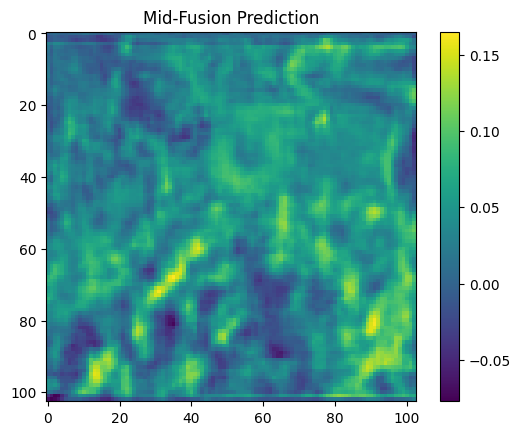

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

--- Mid Fusion Block Importance ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Block SAR: MSE increase 0.000127
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Block DEM: MSE increase 0.000762
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Block Landsat: MSE increase 0.001704
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Block Sentinel2: MSE increase 0.001114
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0791
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - loss: 0.0732
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 0.0751
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.0670
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.0663
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0698
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0697
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.0668
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.0652
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

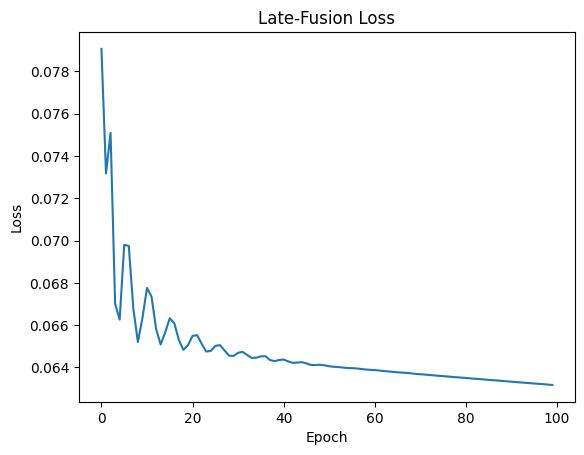

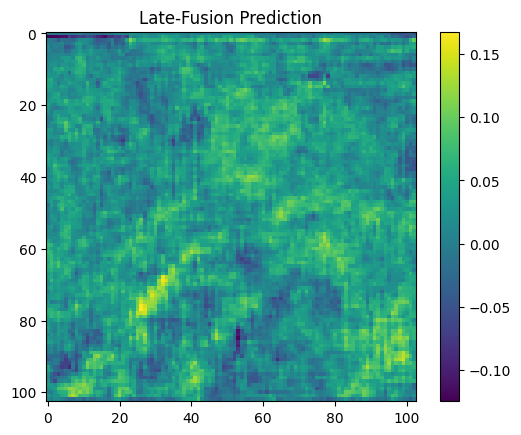

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

--- Late Fusion Block Importance ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Block SAR: MSE increase 0.000792
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Block DEM: MSE increase 0.000780
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Block Landsat: MSE increase 0.003598
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Block Sentinel2: MSE increase 0.002737


In [13]:
import itertools
from sklearn.model_selection import ParameterGrid

# -------------------------------
# Feature importance by permutation
# -------------------------------
def feature_importance(model, X, y, baseline_mse, band_names):
    importance = []
    X_copy = np.copy(X)

    for i, band in enumerate(band_names):
        X_permuted = np.copy(X_copy)
        np.random.shuffle(X_permuted[:, :, i])  # permute single band

        y_pred = model.predict(X_permuted)
        mse = mean_squared_error(y.flatten(), y_pred.flatten())
        delta = mse - baseline_mse
        importance.append((band, delta))
        print(f'Band {band}: MSE increase {delta:.6f}')

    importance.sort(key=lambda x: x[1], reverse=True)
    print("\nFeature Importance Ranking:")
    for band, delta in importance:
        print(f'{band}: {delta:.6f}')

    return importance

# -------------------------------
# Simple hyperparameter grid search
# -------------------------------
def grid_search(build_fn, X, y, param_grid, name):
    best_mse = float('inf')
    best_params = None
    best_model = None

    for params in ParameterGrid(param_grid):
        print(f"Testing {params}")
        model = build_fn(**params)
        model.compile(optimizer=Adam(), loss='mse')
        model.fit(X, y, epochs=5, verbose=0)  # fewer epochs for speed
        y_pred = model.predict(X)
        mse = mean_squared_error(y.flatten(), y_pred.flatten())
        print(f"MSE: {mse:.4f}")

        if mse < best_mse:
            best_mse = mse
            best_params = params
            best_model = model

    print(f"Best {name}-fusion params: {best_params}, MSE: {best_mse:.4f}")
    return best_model, best_params

# -------------------------------
# Train + analyze Early Fusion
# -------------------------------
model_early = build_early_fusion((103, 107, 45))
compile_and_train(model_early, X_train, y_train, 'Early')

y_pred_early = model_early.predict(X_train)
mse_early = mean_squared_error(y_train.flatten(), y_pred_early.flatten())
band_names = [f'Band{i}' for i in range(45)]

print("\n--- Early Fusion Feature Importance ---")
feature_importance(model_early, X_train, y_train, mse_early, band_names)

# -------------------------------
# Hyperparameter grid (example)
# -------------------------------
early_grid = {
    'input_shape': [(103, 107, 45)],
    # Add more grid parameters here if desired
}

best_early_model, best_early_params = grid_search(build_early_fusion, X_train, y_train, early_grid, 'Early')

# -------------------------------
# Train + analyze Mid Fusion
# -------------------------------
SAR_train, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
model_mid = build_mid_fusion()
compile_and_train(model_mid, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, 'Mid')

y_pred_mid = model_mid.predict([SAR_train, dem_train, landsat_train, sentinel_train])
mse_mid = mean_squared_error(y_train.flatten(), y_pred_mid.flatten())
mid_blocks = ['SAR', 'DEM', 'Landsat', 'Sentinel2']

print("\n--- Mid Fusion Block Importance ---")
for i, block in enumerate([SAR_train, dem_train, landsat_train, sentinel_train]):
    X_perm = [np.copy(b) for b in [SAR_train, dem_train, landsat_train, sentinel_train]]
    np.random.shuffle(X_perm[i].reshape(-1, X_perm[i].shape[-1]))  # permute block
    y_pred = model_mid.predict(X_perm)
    mse = mean_squared_error(y_train.flatten(), y_pred.flatten())
    delta = mse - mse_mid
    print(f'Block {mid_blocks[i]}: MSE increase {delta:.6f}')

# -------------------------------
# Train + analyze Late Fusion
# -------------------------------
model_late = build_late_fusion()
compile_and_train(model_late, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, 'Late')

y_pred_late = model_late.predict([SAR_train, dem_train, landsat_train, sentinel_train])
mse_late = mean_squared_error(y_train.flatten(), y_pred_late.flatten())

print("\n--- Late Fusion Block Importance ---")
for i, block in enumerate([SAR_train, dem_train, landsat_train, sentinel_train]):
    X_perm = [np.copy(b) for b in [SAR_train, dem_train, landsat_train, sentinel_train]]
    np.random.shuffle(X_perm[i].reshape(-1, X_perm[i].shape[-1]))  # permute block
    y_pred = model_late.predict(X_perm)
    mse = mean_squared_error(y_train.flatten(), y_pred.flatten())
    delta = mse - mse_late
    print(f'Block {mid_blocks[i]}: MSE increase {delta:.6f}')


hyperprama tuning for fusion

In [16]:
from tensorflow.keras.layers import Dropout

# -------------------------------
# Early Fusion Model with tunable parameters
# -------------------------------
def build_early_fusion(input_shape, filters=32, kernel_size=(3, 3), dropout_rate=0.0):
    inputs = Input(shape=input_shape)
    x = Conv2D(filters, kernel_size, activation='relu', padding='same')(inputs)
    x = Conv2D(filters * 2, kernel_size, activation='relu', padding='same')(x)
    x = Conv2D(filters * 2, kernel_size, activation='relu', padding='same')(x)

    if dropout_rate > 0.0:
        x = Dropout(dropout_rate)(x)

    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model(inputs, x)

# -------------------------------
# Mid Fusion Model with tunable parameters
# -------------------------------
def build_mid_fusion(filters=32, kernel_size=(3, 3), dropout_rate=0.0):
    input_SAR = Input(shape=(103, 107, 8))
    input_dem = Input(shape=(103, 107, 2))
    input_landsat = Input(shape=(103, 107, 23))
    input_sentinel_2 = Input(shape=(103, 107, 12))

    def block(x):
        x = Conv2D(filters, kernel_size, activation='relu', padding='same')(x)
        x = Conv2D(filters * 2, kernel_size, activation='relu', padding='same')(x)
        if dropout_rate > 0.0:
            x = Dropout(dropout_rate)(x)
        return x

    x1 = block(input_SAR)
    x2 = block(input_dem)
    x3 = block(input_landsat)
    x4 = block(input_sentinel_2)

    x = Concatenate()([x1, x2, x3, x4])
    x = Conv2D(filters * 4, kernel_size, activation='relu', padding='same')(x)
    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], x)

# -------------------------------
# Late Fusion Model with tunable parameters
# -------------------------------
def build_late_fusion(filters=32, kernel_size=(3, 3), dropout_rate=0.0):
    input_SAR = Input(shape=(103, 107, 8))
    input_dem = Input(shape=(103, 107, 2))
    input_landsat = Input(shape=(103, 107, 23))
    input_sentinel_2 = Input(shape=(103, 107, 12))

    def block(x):
        x = Conv2D(filters, kernel_size, activation='relu', padding='same')(x)
        if dropout_rate > 0.0:
            x = Dropout(dropout_rate)(x)
        x = Cropping2D(((0, 0), (2, 2)))(x)
        return Conv2D(1, (1, 1), activation='linear', padding='same')(x)

    y1 = block(input_SAR)
    y2 = block(input_dem)
    y3 = block(input_landsat)
    y4 = block(input_sentinel_2)

    y = Add()([y1, y2, y3, y4])
    y = Conv2D(1, (1, 1), activation='linear', padding='same')(y)
    return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], y)


In [17]:
# -------------------------------
# Hyperparameter grid for early fusion
# -------------------------------
early_param_grid = {
    'model_params': [{'input_shape': (103, 107, 45)}],  # Input shape can be customized, but let's assume 45 bands
    'filters': [32, 64, 128],  # Number of filters
    'kernel_size': [(3, 3), (5, 5)],  # Kernel sizes
    'dropout_rate': [0.0, 0.2],  # Dropout rate
    'learning_rate': [1e-3, 1e-4]  # Learning rates
}

# -------------------------------
# Hyperparameter grid for mid/later fusion
# -------------------------------
mid_late_param_grid = {
    'model_params': [{}],  # You may include other parameters, such as kernel_size or filters here
    'filters': [32, 64, 128],
    'kernel_size': [(3, 3), (5, 5)],
    'dropout_rate': [0.0, 0.2],
    'learning_rate': [1e-3, 1e-4]
}

# Perform Grid Search for each fusion type
print("\n--- Hyperparameter tuning: Early Fusion ---")
best_early_model, best_early_params = hyperparameter_grid_search(build_early_fusion, X_train, y_train, early_param_grid, 'Early Fusion')

SAR_train, dem_train, landsat_train, sentinel_train = split_inputs(X_train)

print("\n--- Hyperparameter tuning: Mid Fusion ---")
best_mid_model, best_mid_params = hyperparameter_grid_search(build_mid_fusion, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, mid_late_param_grid, 'Mid Fusion')

print("\n--- Hyperparameter tuning: Late Fusion ---")
best_late_model, best_late_params = hyperparameter_grid_search(build_late_fusion, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, mid_late_param_grid, 'Late Fusion')



--- Hyperparameter tuning: Early Fusion ---

Testing Early Fusion with params: {'model_params': {'input_shape': (103, 107, 45)}, 'filters': 32, 'kernel_size': (3, 3), 'dropout_rate': 0.0, 'learning_rate': 0.001}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
MSE: 0.0653

Testing Early Fusion with params: {'model_params': {'input_shape': (103, 107, 45)}, 'filters': 32, 'kernel_size': (3, 3), 'dropout_rate': 0.0, 'learning_rate': 0.0001}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
MSE: 0.0662

Testing Early Fusion with params: {'model_params': {'input_shape': (103, 107, 45)}, 'filters': 32, 'kernel_size': (3, 3), 'dropout_rate': 0.2, 'learning_rate': 0.001}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
MSE: 0.0646

Testing Early Fusion with params: {'model_params': {'input_shape': (103, 107, 45)}, 'filters': 32, 'kernel_size': (3, 3), 'dropout_rate': 0.2, 'learning_rate': 0.0001}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
MSE: 0.0736

Testing Early Fusion with params: {'model_params': {'input_shape': (103, 107, 4